# Interactive Test Phase — Cross-Modal Cartographer (andito/google-landmarks variant)

Run any sketch + up to two weighted text queries against the **andito/google-landmarks Egypt-subset** FAISS index (photo-filtered).

**Fusion formula:**
$$q = w_s \cdot \Phi(\text{sketch}) + w_{t1} \cdot \Phi(\text{text}_1) + w_{t2} \cdot \Phi(\text{text}_2)$$
Then $q$ is L2-normalised so cosine scores stay in $[0, 1]$.

**Usage:** Edit the query cell below, then run all cells.

In [3]:
# ── Environment guards (must run before any native library import) ────────────
import os
os.environ["OMP_NUM_THREADS"]             = "1"
os.environ["MKL_NUM_THREADS"]             = "1"
os.environ["VECLIB_MAXIMUM_THREADS"]      = "1"
os.environ["NUMEXPR_NUM_THREADS"]         = "1"
os.environ["KMP_DUPLICATE_LIB_OK"]        = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"]      = "false"
os.environ["KMP_INIT_AT_FORK"]            = "FALSE"

import csv, pickle, json, datetime
import numpy as np

import torch
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

import faiss
import clip
from PIL import Image
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model.eval()
print(f"CLIP loaded on {device}")

# ── Load clean FAISS index + metadata ─────────────────────────────────────────
index = faiss.read_index("embeddings/andito_faiss_index_clean.bin")

with open("embeddings/andito_faiss_metadata_clean.pkl", "rb") as f:
    metadata = pickle.load(f)

print(f"FAISS index: {index.ntotal} vectors (andito Egypt subset, photo-filtered)")
print(f"Metadata entries: {len(metadata)}")

CLIP loaded on mps
FAISS index: 3751 vectors (andito Egypt subset, photo-filtered)
Metadata entries: 3751


In [4]:
# ── Core encoding & search functions ──────────────────────────────────────────

def encode_sketch(path: str) -> np.ndarray:
    img = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model.encode_image(img)
        feat /= feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype(np.float32)


def encode_text(text: str) -> np.ndarray:
    tokens = clip.tokenize([text]).to(device)
    with torch.no_grad():
        feat = model.encode_text(tokens)
        feat /= feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype(np.float32)


def multi_fused_query(sketch_path, text1=None, text2=None,
                      w_sketch=0.5, w_text1=0.3, w_text2=0.2):
    """Fuse sketch + up to 2 text queries with independent weights.
    
    Weights are normalised internally so they always sum to 1.
    Set a weight to 0 (or leave text as None/empty) to disable that input.
    """
    components = []
    weights = []

    if sketch_path:
        components.append(encode_sketch(sketch_path))
        weights.append(w_sketch)

    if text1 and text1.strip():
        components.append(encode_text(text1.strip()))
        weights.append(w_text1)

    if text2 and text2.strip():
        components.append(encode_text(text2.strip()))
        weights.append(w_text2)

    if not components:
        raise ValueError("Provide at least one input (sketch or text).")

    # Normalise weights to sum to 1
    total = sum(weights)
    weights = [w / total for w in weights]

    q = sum(w * c for w, c in zip(weights, components))
    q = q / (np.linalg.norm(q, axis=-1, keepdims=True) + 1e-9)
    return q.astype(np.float32), dict(zip(
        ["sketch", "text1", "text2"][:len(weights)], weights))


def faiss_search(query_vec, k=5):
    scores, indices = index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue
        entry = dict(metadata[idx])
        entry["score"] = float(score)
        results.append(entry)
    return results


# ── Zero-shot type classification (for schema check) ─────────────────────────
TYPE_ANCHORS = {
    "Pyramid":      "a photo of an ancient Egyptian pyramid",
    "Mosque":       "a photo of a mosque with domes and minarets",
    "Temple":       "a photo of an ancient Egyptian temple with columns",
    "Palace":       "a photo of an ornate Egyptian palace",
    "Fortress":     "a photo of a stone fortress or citadel",
    "Church":       "a photo of a Coptic Christian church",
    "Museum":       "a photo of a museum building",
    "Monastery":    "a photo of a desert monastery",
    "Natural Site": "a photo of a natural landscape or geological site",
    "Madrassa":     "a photo of an Islamic madrassa school",
}

_anchor_names = list(TYPE_ANCHORS.keys())
_anchor_tokens = clip.tokenize(list(TYPE_ANCHORS.values())).to(device)
with torch.no_grad():
    _anchor_feats = model.encode_text(_anchor_tokens).float()
    _anchor_feats /= _anchor_feats.norm(dim=-1, keepdim=True)
_anchor_feats_np = _anchor_feats.cpu().numpy().astype(np.float32)


def classify_query_type(query_vec):
    sims = (query_vec @ _anchor_feats_np.T).squeeze()
    best_idx = int(np.argmax(sims))
    return _anchor_names[best_idx], float(sims[best_idx])


print("Functions ready.")

Functions ready.


## Configure Your Query

Edit the cell below to set your inputs. Available sketches:
- `pyramid-mid.jpg`, `pyramid-high.png`, `pyramid-low.png`
- `sketch_mosque.png`, `mosque.JPG`
- `sketch_temple.png`, `temple.JPG`

Or use any image path (relative to `V0/`).

**Text 1** = main descriptor (e.g. landmark type, style).  
**Text 2** = location or secondary hint (e.g. city, region, era).  
Leave a text field as `""` to disable it.

In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                        EDIT YOUR QUERY HERE                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

SKETCH_PATH = "temple.jpg"          # path to sketch image (or "" for text-only)

TEXT_1       = "old stone columns"  # main text query
W_TEXT_1     = 0.7                     # weight for text 1

TEXT_2       = ""                      # secondary text (location, era, etc.)
W_TEXT_2     = 0                        # weight for text 2

W_SKETCH     = 0.3                         # weight for sketch

TOP_K        = 10                          # number of results to retrieve
TAU          = 0.60                        # similarity threshold for verification

# ──────────────────────────────────────────────────────────────────────────────
print(f"Sketch:  {SKETCH_PATH or '(none)'}  [w={W_SKETCH}]")
print(f"Text 1:  {TEXT_1 or '(none)'}  [w={W_TEXT_1}]")
print(f"Text 2:  {TEXT_2 or '(none)'}  [w={W_TEXT_2}]")
print(f"Top-k:   {TOP_K}   |   tau: {TAU}")

Sketch:  temple.jpg  [w=0.3]
Text 1:  old stone columns  [w=0.7]
Text 2:  (none)  [w=0]
Top-k:   10   |   tau: 0.6


## Run Query & Display Results

In [6]:
# ── Build fused query & search ────────────────────────────────────────────────
sketch = SKETCH_PATH if SKETCH_PATH else None
t1 = TEXT_1 if TEXT_1 else None
t2 = TEXT_2 if TEXT_2 else None

q, effective_weights = multi_fused_query(
    sketch, text1=t1, text2=t2,
    w_sketch=W_SKETCH, w_text1=W_TEXT_1, w_text2=W_TEXT_2
)

results = faiss_search(q, k=TOP_K)

# ── Zero-shot type classification of the fused query ─────────────────────────
predicted_type, type_conf = classify_query_type(q)

# ── Tau filter ───────────────────────────────────────────────────────────────
accepted = [r for r in results if r["score"] >= TAU]
rejected = [r for r in results if r["score"] < TAU]

# ── Schema check against predicted type ──────────────────────────────────────
for r in accepted:
    r["schema_pass"] = (r["landmark_type"] == predicted_type)

s_violations = [r for r in accepted if not r["schema_pass"]]

# ── Verdict ──────────────────────────────────────────────────────────────────
if not accepted and not rejected:
    verdict = "PHI-failure"
elif not accepted:
    verdict = "TAU-rejection"
elif len(s_violations) == len(accepted):
    verdict = "S-violation"
else:
    verdict = "OK"

# ── Print summary ────────────────────────────────────────────────────────────
print("=" * 80)
print("QUERY SUMMARY")
print("=" * 80)
print(f"  Effective weights: {effective_weights}")
print(f"  Predicted type:    {predicted_type} (conf={type_conf:.3f})")
print(f"  Accepted (>= tau): {len(accepted)}   |   Rejected (< tau): {len(rejected)}")
print(f"  S-violations:      {len(s_violations)}")
print(f"  VERDICT:           {verdict}")
print("=" * 80)

QUERY SUMMARY
  Effective weights: {'sketch': 0.3, 'text1': 0.7}
  Predicted type:    Temple (conf=0.699)
  Accepted (>= tau): 0   |   Rejected (< tau): 10
  S-violations:      0
  VERDICT:           TAU-rejection


In [7]:
# ── Results table ─────────────────────────────────────────────────────────────
print(f"{'Rank':<5} {'Score':<8} {'Pass?':<7} {'Landmark':<40} {'Type':<16} {'Era':<18} {'City'}")
print("-" * 130)
for i, r in enumerate(results, 1):
    above = r["score"] >= TAU
    schema_ok = r.get("schema_pass", True) if above else "-"
    flag = "OK" if (above and schema_ok) else ("S-VIOL" if (above and not schema_ok) else "< tau")
    print(f"{i:<5} {r['score']:<8.4f} {flag:<7} {r['landmark_name']:<40} "
          f"{r['landmark_type']:<16} {r['historical_era']:<18} {r['city']}")

Rank  Score    Pass?   Landmark                                 Type             Era                City
----------------------------------------------------------------------------------------------------------------------------------
1     0.4555   < tau   Archaeological_Park___Pompey_s_Pillar    Garden/Park      Greco-Roman        Alexandria
2     0.4417   < tau   This_appears_to_be_related_to_Bent_Pyramid Pyramid          Pharaonic          Giza
3     0.4390   < tau   Archaeological_Park___Pompey_s_Pillar    Garden/Park      Greco-Roman        Alexandria
4     0.4389   < tau   Temple_of_Dendur                         Temple           Pharaonic          Aswan
5     0.4354   < tau   Temple_of_Dendur                         Temple           Pharaonic          Aswan
6     0.4292   < tau   Coptic_Cairo                             Historical Site  Coptic/Byzantine   Cairo
7     0.4286   < tau   Temple_of_Dendur                         Temple           Pharaonic          Aswan
8     0.428

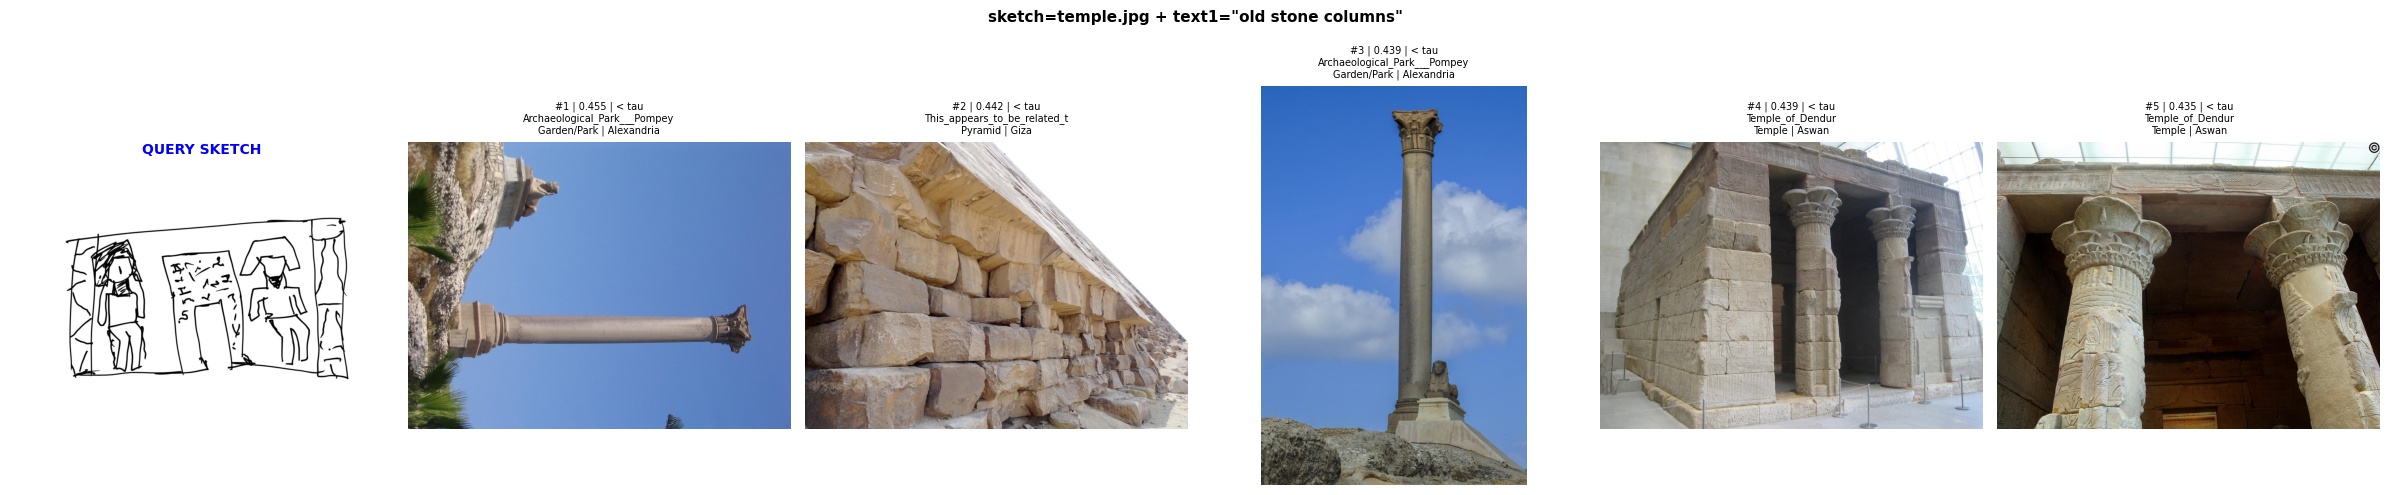

In [8]:
# ── Visual grid: show sketch input + top results ─────────────────────────────
n_show = min(len(results), 5)
n_cols = n_show + (1 if sketch else 0)

fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5))
if n_cols == 1:
    axes = [axes]

col = 0

# Show the query sketch on the left
if sketch:
    axes[col].imshow(mpimg.imread(sketch))
    axes[col].set_title("QUERY SKETCH", fontsize=10, fontweight="bold", color="blue")
    axes[col].axis("off")
    # Draw a blue border
    for spine in axes[col].spines.values():
        spine.set_edgecolor("blue")
        spine.set_linewidth(3)
        spine.set_visible(True)
    col += 1

# Show top-k result images
for i in range(n_show):
    r = results[i]
    try:
        axes[col].imshow(mpimg.imread(r["image_path"]))
    except Exception:
        axes[col].text(0.5, 0.5, "Image\nnot found", ha="center", va="center")

    above = r["score"] >= TAU
    schema_ok = r.get("schema_pass", True)
    if above and schema_ok:
        border_color = "green"
        status = "OK"
    elif above and not schema_ok:
        border_color = "orange"
        status = "S-VIOL"
    else:
        border_color = "red"
        status = "< tau"

    axes[col].set_title(
        f"#{i+1} | {r['score']:.3f} | {status}\n"
        f"{r['landmark_name'][:28]}\n"
        f"{r['landmark_type']} | {r['city']}",
        fontsize=7)
    axes[col].axis("off")
    for spine in axes[col].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
        spine.set_visible(True)
    col += 1

title_parts = []
if sketch:
    title_parts.append(f"sketch={os.path.basename(sketch)}")
if t1:
    title_parts.append(f"text1=\"{t1[:30]}\"")
if t2:
    title_parts.append(f"text2=\"{t2[:30]}\"")
plt.suptitle(" + ".join(title_parts), fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## Comparison: Individual Modalities vs Fused

Shows how each input performs alone vs the combined fusion.

In [9]:
# ── Side-by-side: each modality alone vs fused ───────────────────────────────
modes = {}

if sketch:
    q_s = encode_sketch(sketch)
    modes["Sketch only"] = faiss_search(q_s, k=5)

if t1:
    q_t1 = encode_text(t1)
    modes["Text 1 only"] = faiss_search(q_t1, k=5)

if t2:
    q_t2 = encode_text(t2)
    modes["Text 2 only"] = faiss_search(q_t2, k=5)

modes["FUSED"] = results[:5]

for mode_name, mode_results in modes.items():
    print(f"\n--- {mode_name} ---")
    for i, r in enumerate(mode_results, 1):
        print(f"  {i}. {r['score']:.4f}  {r['landmark_name']:<40} [{r['landmark_type']}]")


--- Sketch only ---
  1. 0.6454  Bibliotheca_Alexandrina                  [Library]
  2. 0.6430  Bibliotheca_Alexandrina                  [Library]
  3. 0.6122  Bibliotheca_Alexandrina                  [Library]
  4. 0.6045  Bibliotheca_Alexandrina                  [Library]
  5. 0.5971  Pyramid_of_Djedkare_Isesi                [Pyramid]

--- Text 1 only ---
  1. 0.3134  Temple_of_Dendur                         [Temple]
  2. 0.3119  Karnak_Temple_Complex                    [Temple]
  3. 0.3069  This_appears_to_be_related_to_Esna_Temple [Temple]
  4. 0.3052  Temple_of_Dendur                         [Temple]
  5. 0.3050  Temple_of_Dendur                         [Temple]

--- FUSED ---
  1. 0.4555  Archaeological_Park___Pompey_s_Pillar    [Garden/Park]
  2. 0.4417  This_appears_to_be_related_to_Bent_Pyramid [Pyramid]
  3. 0.4390  Archaeological_Park___Pompey_s_Pillar    [Garden/Park]
  4. 0.4389  Temple_of_Dendur                         [Temple]
  5. 0.4354  Temple_of_Dendur             

## KG Enrichment (optional — requires Neo4j connection)

Uncomment and run to enrich the top result with Knowledge Graph facts.

In [10]:
# ── KG enrichment for accepted results ────────────────────────────────────────
# Uncomment the block below if you have Neo4j AuraDB running.

# from kg_query import KGClient
# kg = KGClient()
# top_names = [r["landmark_name"] for r in accepted[:5]]
# enriched = kg.enrich(top_names)
# kg.close()
#
# for e in enriched:
#     print(f"\n{'=' * 60}")
#     for k, v in e.items():
#         print(f"  {k:<22} {v}")

# ── Without KG: show metadata we already have ────────────────────────────────
if accepted:
    print("Top accepted results (metadata from registry):\n")
    for i, r in enumerate(accepted[:5], 1):
        print(f"  #{i} {r['landmark_name']}")
        print(f"     Type: {r['landmark_type']}  |  Era: {r['historical_era']}")
        print(f"     City: {r['city']}  |  Region: {r['geographic_region']}")
        print(f"     Style: {r['architectural_style']}")
        print(f"     Coords: ({r['coordinates_lat']}, {r['coordinates_lon']})")
        print()

## Semantic Drift (sketch contribution)

In [11]:
# ── Semantic drift: how much does each modality contribute? ──────────────────
if sketch and (t1 or t2):
    # Build a text-only query (combine text1 + text2 with their relative weights)
    text_components = []
    text_weights = []
    if t1:
        text_components.append(encode_text(t1))
        text_weights.append(W_TEXT_1)
    if t2:
        text_components.append(encode_text(t2))
        text_weights.append(W_TEXT_2)

    tw_total = sum(text_weights)
    text_weights = [w / tw_total for w in text_weights]
    q_text_only = sum(w * c for w, c in zip(text_weights, text_components))
    q_text_only = q_text_only / (np.linalg.norm(q_text_only, axis=-1, keepdims=True) + 1e-9)

    r_text = faiss_search(q_text_only.astype(np.float32), k=5)
    r_fused = results[:5]
    r_sketch = faiss_search(encode_sketch(sketch), k=5)

    mu_sketch = np.mean([r["score"] for r in r_sketch])
    mu_text   = np.mean([r["score"] for r in r_text])
    mu_fused  = np.mean([r["score"] for r in r_fused])
    delta     = mu_fused - mu_text

    print(f"Mean top-5 similarity:")
    print(f"  Sketch-only:  {mu_sketch:.4f}")
    print(f"  Text-only:    {mu_text:.4f}")
    print(f"  Fused:        {mu_fused:.4f}")
    print(f"  delta:        {delta:+.4f}  {'(sketch helps)' if delta > 0 else '(sketch hurts)'}")
else:
    print("Semantic drift requires both sketch and at least one text input.")

Mean top-5 similarity:
  Sketch-only:  0.6205
  Text-only:    0.3085
  Fused:        0.4421
  delta:        +0.1336  (sketch helps)
